# Plotting training results

This notebook serves as a visualization tool for the training results of the **FlowerLLM** training results.
It reads the metric from the training curves directly from Wandb and collect them in `pandas` data frames ready to be analyzed and plotted.

In [90]:
# Imports
from matplotlib import pyplot as plt
import matplotlib.style as mplstyle
import matplotlib.patches as mpatches
import wandb
import pandas as pd
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import enum

# Change font to respect submission requirements
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["font.size"] = 14
plt.rcParams["font.weight"] = "bold"
# Colors and line styles
color_palette = sns.color_palette("colorblind")
line_styles = ["-", "--", ":", "-."]
# Bolded axis labels
plt.rcParams["axes.labelweight"] = "bold"
mplstyle.use("fast")

In [91]:
class CentSuffix(str, enum.Enum):
    """Enum class for suffixes of centralized runs."""

    CENTRALIZED = "_centralised"
    CLIENT_0 = "_client_0"
    NONE = ""

In [92]:
# Set the run_id to be retrieved
run_id_dict = {
    "fed-1B-short": [
        ("fed-1B-20240322_221900-fix-nesto", 8),
        # ("fed-1B-20240509_061535", 8),
        ("fed-1B-20240510_074507", 8),
    ],
    "fed-1B-long": [
        ("fed-1B-20240314_232607", 8),
    ],
    "cen-1B": [
        ("centralised-1B-20240229_104204", CentSuffix.NONE),
    ],
    "fed-350M": [
        ("fed-350M-20240506_204125", 8),
        ("fed-350M-20240505_100605", 8),
    ],
    "cen-350M": [
        ("centralised-350M-20240305_191112", CentSuffix.NONE),
    ],
    "fed-160M": [],
    "cen-160M": [],
    "fed-125M": [
        ("fed-125M-20240502_203012-continue-3", 8),
        ("fed-125M-20240502_203012", 8),
    ],
    "cen-125M": [("centralised-125M-20240510_095447_client_0", CentSuffix.CLIENT_0)],
    "fed-75M": [("fed-75M-20240506_234900", 8)],
    "cen-75M": [("centralised-75M-20240508_212653", CentSuffix.CLIENT_0)],
    "fed-pile-75M-8": [
        ("pile-75M-final-20240605_133225-con", 8, True, False),
        ("pile-75M-final-20240605_133225", 8, True, False),
    ],
    "fed-pile-125M-8": [
        ("pile-125M-final-20240608_174142", 8, True, False),
    ],
    "cen-pile-75M-8": [("pile-75M-cent-20240607_105615", CentSuffix.CENTRALIZED)],
    "cen-pile-125M-8": [("pile-125M-cent-20240607_225637", CentSuffix.CENTRALIZED)],
    "fed-partial-75M-4_64": [("partial-75M-20240610_135450", 64)],
    "cen-partial-75M-4_64": [("centralised-75M-20240508_212653", CentSuffix.CLIENT_0)],
    "fed-partial-125M-4_64": [("partial-125M-20240611_011620", 64)],
    "cen-partial-125M-4_64": [
        ("centralised-125M-20240510_095447_client_0", CentSuffix.CLIENT_0)
    ],
}

In [93]:
# Server metrics columns
server_metrics_columns = [
    # Train-specific metrics
    "LanguageCrossEntropy",
    "LanguagePerplexity",
    # Val-specific metrics
    "ValLanguageCrossEntropy",
    "ValLanguagePerplexity",
    # Wandb internals
    "_runtime",
    "_step",
    "_timestamp",
    # Client-side bookkeeping
    "client/eval_init_time",
    "client/eval_metrics_collection_time",
    "client/eval_time",
    "client/eval_trainer_closing_time",
    "client/fit_get_parameters_time",
    "client/fit_init_time",
    "client/fit_metrics_collection_time",
    "client/fit_time",
    "client/fit_trainer_closing_time",
    # Client-side metrics
    "client/l2_norm_pseudo_gradient",
    "client_state_acc",
    "distributed_loss",
    # Node-side bookkeeping
    "node_eval_time_s",
    "node_training_time_s",
    # Server-side bookkeeping
    "server/evaluate_round_time",
    "server/evaluate_time",
    "server/first_check_nm_time",
    "server/fit_round_time",
    "server/round_time",
    "server/second_check_nm_time",
    # Server-side computed norms
    "server/l2_norm_fedavg_result",
    "server/l2_norm_model",
    "server/l2_norm_momentum_vector",
    "server/l2_norm_pseudo_gradient",
    # Step
    "step",
    # Worker-side bookkeeping
    "worker/partial_aggregation_time",
]

In [94]:
# Client metrics columns
client_metrics_columns = [
    # Wandb internals
    "_runtime",
    "_step",
    "_timestamp",
    # Activation norms
    "activations/l2_norm/full_model_input",
    "activations/l2_norm/full_model_output",
    # CID
    "client_id",
    # Momentum, gradient and model norms
    "l2_norm/grad/global",
    "l2_norm/moment/global",
    "l2_norm/param/global",
    "l2_norm/update/global",
    # Train loss
    "loss/train/total",
    # LR
    "lr-DecoupledAdamW/group0",
    # Memory metrics
    "memory/alloc_retries",
    "memory/current_active_mem",
    "memory/current_allocated_mem",
    "memory/current_inactive_mem",
    "memory/current_reserved_mem",
    "memory/peak_active_mem",
    "memory/peak_allocated_mem",
    "memory/peak_inactive_mem",
    "memory/peak_reserved_mem",
    "metrics/train/LanguageCrossEntropy",
    "metrics/train/LanguagePerplexity",
    # Step
    "step",
    # Throughput metrics
    "throughput/batches_per_sec",
    "throughput/device/batches_per_sec",
    "throughput/device/flops_per_sec",
    "throughput/device/mfu",
    "throughput/device/samples_per_sec",
    "throughput/device/tokens_per_sec",
    "throughput/flops_per_sec",
    "throughput/samples_per_sec",
    "throughput/tokens_per_sec",
    # Time metrics
    "time/batch",
    "time/batch_in_epoch",
    "time/epoch",
    "time/remaining_estimate",
    "time/sample",
    "time/sample_in_epoch",
    "time/token",
    "time/token_in_epoch",
    "time/total",
    "time/train",
    "time/val",
    # Microbatch size
    "trainer/device_train_microbatch_size",
]

In [95]:
x_lim: tuple[float, float] | None = None
perplexity_y_lim: dict[str, float] | None = {"top": 225, "bottom": 0}
norm_y_lim: dict[str, float] | None = {"bottom": 300, "top": 900}
momentum_y_lim: dict[str, float] | None = {"bottom": 300, "top": 900}
grad_y_lim: dict[str, float] | None = {"bottom": 0, "top": 125}
grad_client_y_lim: dict[str, float] | None = {"bottom": 0, "top": 1.6}
lr_y_lim: dict[str, float] | None = None
act_out_y_lim: dict[str, float] | None = None
act_out_y_lim: dict[str, float] | None = {"bottom": 0, "top": 1.3 * 1e7}

In [96]:
def download_metrics(
    run_id: str, n_clients: int, drop_layers: bool = True, use_server_name: bool = False
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Download all the metrics from given run_id using Wandb API."""
    # Initialize the wandb API
    api = wandb.Api(timeout=100)
    # Get the run object
    server_run = (
        api.run(f"camlsys/pollen-llm/{run_id}_server")
        if use_server_name
        else api.run(f"camlsys/pollen-llm/{run_id}")
    )
    # Get the metrics
    server_metrics = server_run.scan_history()
    # Convert the metrics to a pandas data frame
    server_metrics_df = pd.DataFrame(server_metrics)
    # Drop the layers columns if needed
    if drop_layers:
        layer_columns = [col for col in server_metrics_df.columns if "layer" in col]
        server_metrics_df = server_metrics_df.drop(columns=layer_columns)
    # Add the `step` column based on the index
    server_metrics_df["step"] = server_metrics_df.index
    # Get clients metrics
    clients_metrics_df_list: list[pd.DataFrame] = []

    for i in range(n_clients):
        try:
            # Get the run object

            client_run = (
                api.run(f"camlsys/pollen-llm/{run_id}_client_{i}")
                if (
                    run_id != "pile-75M-final-20240605_133225"
                    and run_id != "partial-75M-20240605_133326"
                )
                else api.run(f"camlsys/pollen-llm/{run_id}client_{i}")
            )
            # Get the metrics
            client_metrics = client_run.scan_history()
            # Convert the metrics to a pandas data frame
            client_metrics_df = pd.DataFrame(client_metrics)
            # Drop the layers columns if needed
            if drop_layers:
                layer_columns = [
                    col for col in client_metrics_df.columns if "layer" in col
                ]
                client_metrics_df = client_metrics_df.drop(columns=layer_columns)
            # Add the `step` column based on the index
            client_metrics_df["step"] = client_metrics_df._step
            # Add the `client_id` column based on the current client_id
            client_metrics_df["client_id"] = i
            # Append the client metrics to the list
            clients_metrics_df_list.append(client_metrics_df)
        except:
            print(f"Client {i} not found for run {run_id}")
    # Concatenate the clients metrics
    clients_metrics_df = pd.concat(clients_metrics_df_list)
    # Return the metrics data frame
    return server_metrics_df, clients_metrics_df

In [97]:
def download_metrics_centralized(
    run_id: str,
    suffix: str,
) -> pd.DataFrame:
    """Download all the metrics from given run_id using Wandb API."""
    # Initialize the wandb API
    api = wandb.Api()
    # Get the run object
    cent_run = api.run(f"camlsys/pollen-llm/{run_id}{suffix}")
    # Get the metrics
    cent_metrics = cent_run.scan_history()
    # Convert the metrics to a pandas data frame
    cent_metrics_df = pd.DataFrame(cent_metrics)

    # Add the `step` column based on the index
    cent_metrics_df["step"] = cent_metrics_df.index

    # Return the metrics data frame
    return cent_metrics_df

In [98]:
# data_frames = download_metrics(
#     run_id_dict["fed-1B-long"][0][0], run_id_dict["fed-1B-long"][0][1]
# )
# server_data_frame, clients_data_frame = data_frames[0], data_frames[1]

In [99]:
# server_df_list: list[pd.DataFrame] = []
# clients_df_list: list[pd.DataFrame] = []
# centralized_df_list: list[pd.DataFrame] = []
# file_name = "1s.pdf"
# x_lim = (0,14)
# for record in run_id_dict["fed-1B-long"]:
#     data_frames = download_metrics(*record)
#     server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
#     server_df_list.append(server_data_frame)
#     clients_df_list.append(clients_data_frame)
# server_data_frame = pd.concat(server_df_list)
# clients_data_frame = pd.concat(clients_df_list)
# for record in run_id_dict["cen-1B"]:
#     data_frames = download_metrics_centralized(*record)
#     centralized_df_list.append(data_frames)
# centralized_df = pd.concat(centralized_df_list)

In [100]:
# server_df_list: list[pd.DataFrame] = []
# clients_df_list: list[pd.DataFrame] = []
# centralized_df_list: list[pd.DataFrame] = []
# centralized_df_list: list[pd.DataFrame] = []
# file_name = "350.pdf"
# x_lim = (0,40)
# for record in run_id_dict["fed-350M"]:
#     data_frames = download_metrics(record[0], record[1])
#     server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
#     server_df_list.append(server_data_frame)
#     clients_df_list.append(clients_data_frame)
# server_data_frame = pd.concat(server_df_list)
# clients_data_frame = pd.concat(clients_df_list)
# for record in run_id_dict["cen-350M"]:
#     data_frames = download_metrics_centralized(*record)
#     centralized_df_list.append(data_frames)
# centralized_df = pd.concat(centralized_df_list)

In [101]:
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
centralized_df_list: list[pd.DataFrame] = []
file_name = "125.pdf"
x_lim = (0, 40)
for record in run_id_dict["fed-125M"]:
    data_frames = download_metrics(record[0], record[1])
    server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
    server_df_list.append(server_data_frame)
    clients_df_list.append(clients_data_frame)
server_data_frame = pd.concat(server_df_list)
clients_data_frame = pd.concat(clients_df_list)
for record in run_id_dict["cen-125M"]:
    data_frames = download_metrics_centralized(*record)
    centralized_df_list.append(data_frames)
centralized_df = pd.concat(centralized_df_list)

In [102]:
# server_df_list: list[pd.DataFrame] = []
# clients_df_list: list[pd.DataFrame] = []
# centralized_df_list: list[pd.DataFrame] = []
# file_name = "1s.pdf"
# for record in run_id_dict["fed-1B-short"]:
#     data_frames = download_metrics(record[0], record[1])
#     server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
#     server_df_list.append(server_data_frame)
#     clients_df_list.append(clients_data_frame)
# server_data_frame = pd.concat(server_df_list)
# clients_data_frame = pd.concat(clients_df_list)
# for record in run_id_dict["cen-1B"]:
#     data_frames = download_metrics_centralized(*record)
#     centralized_df_list.append(data_frames)
# centralized_df = pd.concat(centralized_df_list)

In [103]:
# file_name = "75.pdf"
# x_lim = (0,40)
# server_df_list: list[pd.DataFrame] = []
# clients_df_list: list[pd.DataFrame] = []
# centralized_df_list: list[pd.DataFrame] = []
# for record in run_id_dict["fed-75M"]:
#     data_frames = download_metrics(record[0], record[1])
#     server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
#     server_df_list.append(server_data_frame)
#     clients_df_list.append(clients_data_frame)
# server_data_frame = pd.concat(server_df_list)
# clients_data_frame = pd.concat(clients_df_list)
# for record in run_id_dict["cen-75M"]:
#     data_frames = download_metrics_centralized(*record)
#     centralized_df_list.append(data_frames)
# centralized_df = pd.concat(centralized_df_list)

In [104]:
# file_name = "pile-75.pdf"
# x_lim = (0,40)
# server_df_list: list[pd.DataFrame] = []
# clients_df_list: list[pd.DataFrame] = []
# centralized_df_list: list[pd.DataFrame] = []
# for record in run_id_dict["fed-pile-75M-8"]:
#     data_frames = download_metrics(*record)
#     server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
#     server_df_list.append(server_data_frame)
#     clients_df_list.append(clients_data_frame)
# server_data_frame = pd.concat(server_df_list)
# clients_data_frame = pd.concat(clients_df_list)
# for record in run_id_dict["cen-pile-75M-8"]:
#     data_frames = download_metrics_centralized(record[0])
#     centralized_df_list.append(data_frames)
# centralized_df = pd.concat(centralized_df_list)

In [105]:
# file_name = "pile-125.pdf"
# x_lim = (0,25)
# server_df_list: list[pd.DataFrame] = []
# clients_df_list: list[pd.DataFrame] = []
# centralized_df_list: list[pd.DataFrame] = []
# for record in run_id_dict["fed-pile-125M-8"]:
#     data_frames = download_metrics(*record)
#     server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
#     server_df_list.append(server_data_frame)
#     clients_df_list.append(clients_data_frame)
# server_data_frame = pd.concat(server_df_list)
# clients_data_frame = pd.concat(clients_df_list)
# for record in run_id_dict["cen-pile-125M-8"]:
#     data_frames = download_metrics_centralized(record[0])
#     centralized_df_list.append(data_frames)
# centralized_df = pd.concat(centralized_df_list)

In [106]:
# file_name = "partial-75.pdf"
# x_lim = (0,40)
# server_df_list: list[pd.DataFrame] = []
# clients_df_list: list[pd.DataFrame] = []
# centralized_df_list: list[pd.DataFrame] = []
# for record in run_id_dict["fed-partial-75M-4_64"]:
#     data_frames = download_metrics(record[0], record[1])
#     server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
#     server_df_list.append(server_data_frame)
#     clients_df_list.append(clients_data_frame)
# server_data_frame = pd.concat(server_df_list)
# clients_data_frame = pd.concat(clients_df_list)
# for record in run_id_dict["cen-partial-75M-4_64"]:
#     data_frames = download_metrics_centralized(*record)
#     centralized_df_list.append(data_frames)
# centralized_df = pd.concat(centralized_df_list)

In [107]:
# file_name = "partial-125.pdf"
# x_lim = (0,25)
# server_df_list: list[pd.DataFrame] = []
# clients_df_list: list[pd.DataFrame] = []
# centralized_df_list: list[pd.DataFrame] = []
# for record in run_id_dict["fed-partial-125M-4_64"]:
#     data_frames = download_metrics(record[0], record[1])
#     server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
#     server_df_list.append(server_data_frame)
#     clients_df_list.append(clients_data_frame)
# server_data_frame = pd.concat(server_df_list)
# clients_data_frame = pd.concat(clients_df_list)
# for record in run_id_dict["cen-partial-125M-4_64"]:
#     data_frames = download_metrics_centralized(*record)
#     centralized_df_list.append(data_frames)
# centralized_df = pd.concat(centralized_df_list)

In [108]:
def plot_single_federated_run_ppl(
    server_data_frame: pd.DataFrame,
    clients_data_frame: pd.DataFrame,
    centralized_data_frame: pd.DataFrame | None = None,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
    y_lim: dict[str, float] | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    plt.figure(figsize=(10, 5))

    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    # Remove data points past the x_lim

    if x_lim:
        tmp_clients_data_frame = tmp_clients_data_frame[
            tmp_clients_data_frame["_step"] <= x_lim[1]
        ]
        tmp_server_data_frame = tmp_server_data_frame[
            tmp_server_data_frame["_step"] <= x_lim[1]
        ]

    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="ValLanguagePerplexity",
        label="Server Validation PPL",
        alpha=0.5,
        color=color_palette[0],
        linestyle=line_styles[0],
    )
    # sns.lineplot(
    #     data=tmp_server_data_frame,
    #     x="_step",
    #     y="LanguagePerplexity",
    #     label="Mean Train PPL",
    #     alpha=0.5,
    #     color=color_palette[1],
    #     linestyle=line_styles[0],
    # )

    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="metrics/train/LanguagePerplexity",
        label="Client Train PPL",
        alpha=0.5,
        color=color_palette[1],
        linestyle=line_styles[1],
    )
    if centralized_data_frame is not None:
        # Sort `centralized_data_frame` by `_step`
        tmp_centralized_data_frame = centralized_data_frame.sort_values(by="_step")
        tmp_centralized_data_frame = tmp_centralized_data_frame[
            tmp_centralized_data_frame["_step"] % 10 == 0
        ]
        tmp_centralized_data_frame["_step"] = tmp_centralized_data_frame["_step"] / 500
        # Reset the index of `centralized_data_frame`
        tmp_centralized_data_frame = tmp_centralized_data_frame.reset_index(drop=True)
        if x_lim:
            tmp_centralized_data_frame = tmp_centralized_data_frame[
                tmp_centralized_data_frame["_step"] <= x_lim[1]
            ]
        sns.lineplot(
            data=tmp_centralized_data_frame,
            x="_step",
            y="metrics/eval/LanguagePerplexity",
            label="Centralized Validation PPL",
            alpha=0.5,
            color=color_palette[2],
            linestyle=line_styles[2],
        )
        sns.lineplot(
            data=tmp_centralized_data_frame,
            x="_step",
            y="metrics/train/LanguagePerplexity",
            label="Centralized Train PPL",
            alpha=0.5,
            color=color_palette[3],
            linestyle=line_styles[2],
        )
    # Set mthe maximum y-axis limit to 500
    # if x_lim:
    #     plt.xlim(x_lim)
    if y_lim:
        plt.ylim(**y_lim)

    plt.gca().yaxis.set_minor_locator(MultipleLocator(5))
    plt.grid(which="major")
    plt.minorticks_on()  # Turn on the minor ticks
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("PPL")
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

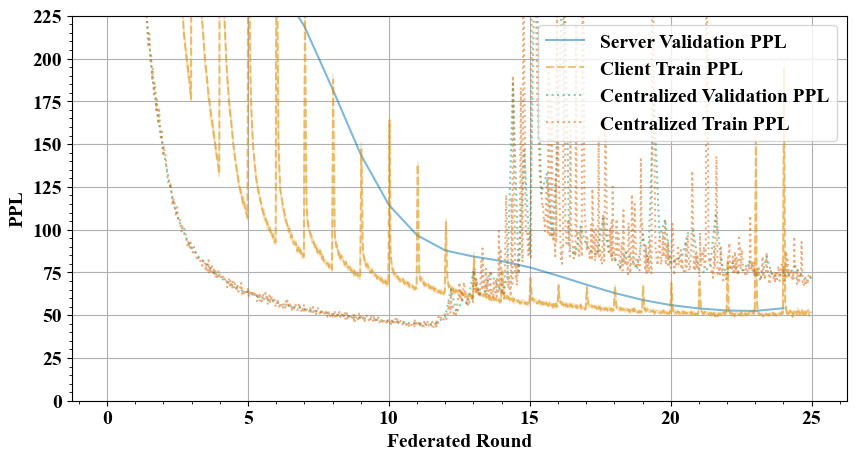

In [109]:
plot_single_federated_run_ppl(
    server_data_frame,
    clients_data_frame,
    centralized_df,
    file_name=f"perplexity_{file_name}",
    x_lim=x_lim,
    y_lim=perplexity_y_lim,
)

In [110]:
def plot_single_federated_run_l2_model(
    server_data_frame: pd.DataFrame,
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
    y_lim: dict[str, float] | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values

    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]

    if x_lim:
        tmp_clients_data_frame = tmp_clients_data_frame[
            tmp_clients_data_frame["_step"] <= x_lim[1]
        ]
        tmp_server_data_frame = tmp_server_data_frame[
            tmp_server_data_frame["_step"] <= x_lim[1]
        ]

    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_model",
        label="Global Model L2 Norm",
        alpha=0.5,
        color=color_palette[0],
        linestyle=line_styles[0],
    )
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_fedavg_result",
        label="Global Model L2 Norm - FedAvg",
        alpha=0.5,
        color=color_palette[1],
        linestyle=line_styles[0],
    )

    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="l2_norm/param/global",
        label="Client Model L2 Norm",
        alpha=0.5,
        color=color_palette[3],
        linestyle=line_styles[1],
    )
    # if x_lim:
    #     plt.xlim(x_lim)
    if y_lim:
        plt.ylim(**y_lim)
    plt.gca().yaxis.set_minor_locator(MultipleLocator(25))
    plt.grid(which="major")
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("Model L2 Norm")
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

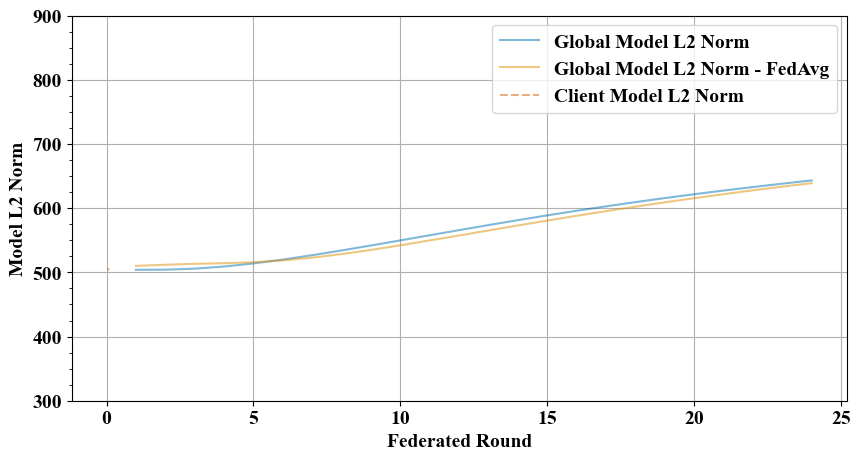

In [111]:
try:
    plot_single_federated_run_l2_model(
        server_data_frame,
        clients_data_frame,
        file_name=f"l2_{file_name}",
        x_lim=x_lim,
        y_lim=norm_y_lim,
    )
except:
    print("No L2 model norm to plot")

In [112]:
def plot_single_federated_run_l2_global_momentum(
    server_data_frame: pd.DataFrame,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
    y_lim: dict[str, float] | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values

    if x_lim:
        tmp_server_data_frame = tmp_server_data_frame[
            tmp_server_data_frame["_step"] <= x_lim[1]
        ]
    plt.figure(figsize=(10, 5))
    patches = []
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_momentum_vector",
        label="Global Momentum",
        alpha=0.5,
        color=color_palette[0],
        linestyle=line_styles[0],
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[0],
            linestyle=line_styles[0],
            label="Global Momentum",
        )
    )
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_model",
        label="Global Model",
        alpha=0.5,
        color=color_palette[1],
        linestyle=line_styles[0],
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[1],
            linestyle=line_styles[0],
            label="Global Model",
        )
    )
    # if x_lim:
    #     plt.xlim(x_lim)
    if y_lim:
        plt.ylim(**y_lim)
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("L2 Norm")
    plt.gca().yaxis.set_minor_locator(MultipleLocator(25))
    plt.grid(which="major")
    # Add the legend manually
    plt.legend(loc="right", handles=patches)
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

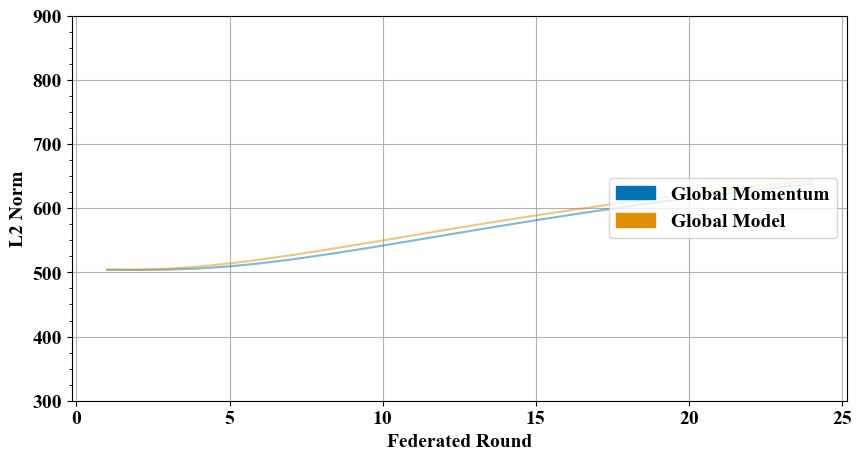

In [113]:
try:
    plot_single_federated_run_l2_global_momentum(
        server_data_frame,
        file_name=f"nesterov_{file_name}",
        x_lim=x_lim,
        y_lim=momentum_y_lim,
    )
except:
    print("No L2 momentum norm to plot")

In [114]:
def plot_single_federated_run_l2_gradient(
    server_data_frame: pd.DataFrame,
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
    y_lim: dict[str, float] | None = None,
    client_y_lim: dict[str, float] | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    if x_lim:
        tmp_clients_data_frame = tmp_clients_data_frame[
            tmp_clients_data_frame["_step"] <= x_lim[1]
        ]
        tmp_server_data_frame = tmp_server_data_frame[
            tmp_server_data_frame["_step"] <= x_lim[1]
        ]

    plt.figure(figsize=(10, 5))
    patches = []
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_pseudo_gradient",
        label="FedAvg Pseudo-Gradient",
        alpha=0.5,
        color=color_palette[0],
        linestyle=line_styles[0],
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[0],
            linestyle=line_styles[0],
            label="FedAvg Pseudo-Gradient",
        )
    )

    # Add a new y-axis for the next plot
    plt.ylabel("Server L2 Norm")
    plt.xlabel("Federated Round")

    if y_lim:
        plt.ylim(**y_lim)

    plt.grid()
    plt.legend().remove()
    ax2 = plt.twinx()
    if client_y_lim:
        ax2.set_ylim(**client_y_lim)  # type: ignore[reportArgumentType]
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="l2_norm/grad/global",
        label="Client Computed Step-Gradient",
        alpha=0.5,
        ax=ax2,
        color=color_palette[1],
        linestyle=line_styles[1],
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[1],
            linestyle=line_styles[1],
            label="Client Computed Step-Gradient",
        )
    )
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="l2_norm/update/global",
        label="Client Applied Step-Gradient",
        alpha=0.5,
        ax=ax2,
        color=color_palette[2],
        linestyle=line_styles[1],
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[2],
            linestyle=line_styles[1],
            label="Client Applied Step-Gradient",
        )
    )
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("Client L2 Norm")
    # Add the legend manually
    plt.legend(loc="right", handles=patches)
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

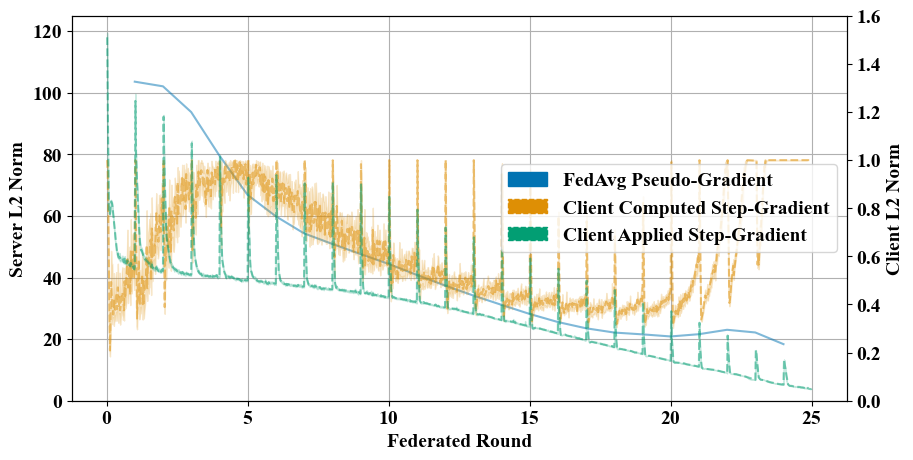

In [115]:
try:
    plot_single_federated_run_l2_gradient(
        server_data_frame,
        clients_data_frame,
        file_name=f"cdf_{file_name}",
        x_lim=x_lim,
        y_lim=grad_y_lim,
        client_y_lim=grad_client_y_lim,
    )
except:
    print("No L2 gradient norm to plot")

In [116]:
def plot_single_federated_run_lr(
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
    y_lim: dict[str, float] | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    plt.figure(figsize=(10, 5))
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    # Add a new y-axis for the next plot
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="lr-DecoupledAdamW/group0",
        alpha=0.5,
        color=color_palette[2],
        linestyle=line_styles[1],
    )
    # if x_lim:
    #     plt.xlim(x_lim)
    if y_lim:
        plt.ylim(**y_lim)
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("Client Learning Rate")
    plt.grid()
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

In [117]:
# plot_single_federated_run_lr(clients_data_frame, file_name=f"lr_{file_name}", x_lim=x_lim, y_lim=lr_y_lim)

In [118]:
def plot_single_federated_run_output_activation(
    clients_data_frame: pd.DataFrame,
    centralized_data_frame: pd.DataFrame | None = None,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
    y_lim: dict[str, float] | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    plt.figure(figsize=(10, 5))
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500

    if x_lim:
        tmp_clients_data_frame = tmp_clients_data_frame[
            tmp_clients_data_frame["_step"] <= x_lim[1]
        ]

    # Add a new y-axis for the next plot
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="activations/l2_norm/full_model_output",
        alpha=0.5,
        color=color_palette[3],
        label="Client Output Activations",
        linestyle=line_styles[1],
    )
    if centralized_data_frame is not None:
        tmp_centralized_data_frame = centralized_data_frame.sort_values(by="_step")
        tmp_centralized_data_frame = tmp_centralized_data_frame[
            tmp_centralized_data_frame["_step"] % 10 == 0
        ]
        tmp_centralized_data_frame["_step"] = tmp_centralized_data_frame["_step"] / 500
        tmp_centralized_data_frame = tmp_centralized_data_frame.reset_index(drop=True)

        if x_lim:
            tmp_centralized_data_frame = tmp_centralized_data_frame[
                tmp_centralized_data_frame["_step"] <= x_lim[1]
            ]

        sns.lineplot(
            data=tmp_centralized_data_frame,
            x="_step",
            y="activations/l2_norm/full_model_output",
            alpha=0.5,
            color=color_palette[4],
            label="Centralized Output Activations",
            linestyle=line_styles[0],
        )

    # Set x and y labels

    plt.xlabel("Federated Round")
    plt.ylabel("L2 Norm")
    # if x_lim:
    #     plt.xlim(x_lim)
    if y_lim:
        plt.ylim(**y_lim)

    # plt.legend()
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

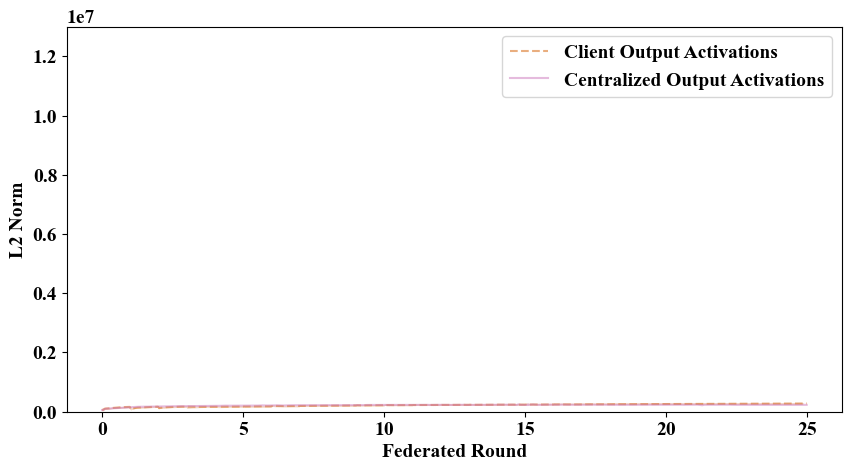

In [119]:
try:
    plot_single_federated_run_output_activation(
        clients_data_frame,
        centralized_data_frame=centralized_df,
        file_name=f"act_out_{file_name}",
        x_lim=x_lim,
        y_lim=act_out_y_lim,
    )
except:
    print("No output activation norm to plot")

In [120]:
def plot_single_federated_run_input_activation(
    clients_data_frame: pd.DataFrame,
    centralized_data_frame: pd.DataFrame | None = None,
    file_name: str | None = None,
    x_lim: tuple[float, float] | None = None,
    y_lim: tuple[float, float] | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    plt.figure(figsize=(10, 5))
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    if x_lim:
        tmp_clients_data_frame = tmp_clients_data_frame[
            tmp_clients_data_frame["_step"] <= x_lim[1]
        ]

    # Add a new y-axis for the next plot
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="activations/l2_norm/full_model_input",
        alpha=0.5,
        color=color_palette[3],
        label="Client Input Activations",
        linestyle=line_styles[1],
    )
    if centralized_data_frame is not None:
        tmp_centralized_data_frame = centralized_data_frame.sort_values(by="_step")
        tmp_centralized_data_frame = tmp_centralized_data_frame[
            tmp_centralized_data_frame["_step"] % 10 == 0
        ]
        tmp_centralized_data_frame["_step"] = tmp_centralized_data_frame["_step"] / 500
        tmp_centralized_data_frame = tmp_centralized_data_frame.reset_index(drop=True)

        if x_lim:
            tmp_centralized_data_frame = tmp_centralized_data_frame[
                tmp_centralized_data_frame["_step"] <= x_lim[1]
            ]

        sns.lineplot(
            data=tmp_centralized_data_frame,
            x="_step",
            y="activations/l2_norm/full_model_input",
            alpha=0.5,
            color=color_palette[4],
            label="Centralized Input Activations",
            linestyle=line_styles[0],
        )

    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("L2 Norm")
    plt.grid()
    # plt.legend()
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

In [121]:
# plot_single_federated_run_input_activation(
#     clients_data_frame,
#     centralized_data_frame=centralized_df,
#     file_name=f"act_input_{file_name}",
#     x_lim=x_lim,
#     y_lim=act_out_y_lim,
# )

In [122]:
# TODO: PPLs comparing federated against centralised in the same plot (3+2 lines)
# TODO: Model L2 Norm comparing federated against centralised in the same plot (3+1 lines)
# TODO: Activations L2 Norm comparing federated against centralised in the same plot (1+1 lines, at most 2+2 lines)

In [123]:
# server_df_list: list[pd.DataFrame] = []
# clients_df_list: list[pd.DataFrame] = []
# for record in run_id_dict["fed-350M"]:
#     data_frames = download_metrics(record[0], record[1], drop_layers=False)
#     server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
#     server_df_list.append(server_data_frame)
#     clients_df_list.append(clients_data_frame)
# server_data_frame = pd.concat(server_df_list).dropna()
# clients_data_frame = pd.concat(clients_df_list).dropna()

In [124]:
def plot_block_wise_heatmap(
    server_data_frame: pd.DataFrame,
    layer_wise_metric: str = "/l2_norm_pseudo_gradient",
    block_size=12,
    cmap="coolwarm",
    normalize=False,
) -> None:
    """Plot a heatmap with the round as the x-axis and the layer index as the y-axis.
    Layers are processed in blocks of block_size starting from the end
    """
    layer_df = server_data_frame.filter(like=layer_wise_metric)
    stripped_columns = layer_df.rename(
        columns=lambda x: x.replace(layer_wise_metric, "")
    )
    stripped_columns = stripped_columns.rename(
        columns=lambda x: x.replace("server/layer/", "")
    )
    # stripped_columns = stripped_columns.drop(columns=["server", "client"])
    stripped_columns = stripped_columns.drop(columns=["server"])
    print(stripped_columns.columns)
    new_columns = {
        col: pd.to_numeric(col, errors="coerce") for col in stripped_columns.columns
    }
    numeric_columns = stripped_columns.rename(columns=new_columns)
    sorted_columns = numeric_columns.sort_index(axis=1, ascending=True)
    print(sorted_columns)
    transposed_dataframe = sorted_columns.T

    if normalize:
        transposed_dataframe = transposed_dataframe.apply(
            lambda x: (x - x.min()) / (x.max() - x.min()), axis=1
        )

    for i in range(len(transposed_dataframe) - 1, -1, -block_size):
        # Select the columns for this heatmap
        start = max(0, i - block_size + 1)
        end = i + 1
        subset = transposed_dataframe.iloc[start:end]

        # Create the heatmap
        sns.heatmap(subset, cmap=cmap)
        plt.title(f"Heatmap for layers {start} to {end}")
        plt.xlabel("Round")
        plt.ylabel("Layer Index")
        plt.savefig(f"norm_heatmap_{i}")
        plt.close()

In [125]:
# plot_block_wise_heatmap(server_data_frame, layer_wise_metric="/l2_norm_model")

In [126]:
# plot_block_wise_heatmap(
#     server_data_frame, layer_wise_metric="/l2_norm_model", normalize=True
# )